In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ده مثال عشان اجرب الكود
n_features = 30
np.random.seed(42)
parent1 = np.random.randint(0, 2, n_features)
parent2 = np.random.randint(0, 2, n_features)

print("Parent 1:", parent1)
print("Parent 2:", parent2)

Parent 1: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1]
Parent 2: [0 0 1 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 0]


In [4]:
def single_point_crossover(parent1, parent2):
    point = np.random.randint(1, len(parent1) - 1)

    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])

    return child1, child2


c1, c2 = single_point_crossover(parent1, parent2)

print("Single Point Results:")
print("Child 1:", c1)
print("Child 2:", c2)

Single Point Results:
Child 1: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0]
Child 2: [0 0 1 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1]


In [5]:
def uniform_crossover(parent1, parent2, prob=0.5):
    mask = np.random.rand(len(parent1)) < prob

    child1 = np.where(mask, parent1, parent2)
    child2 = np.where(mask, parent2, parent1)

    return child1, child2


c1, c2 = uniform_crossover(parent1, parent2)

print("Uniform Crossover Results:")
print("Child 1:", c1)
print("Child 2:", c2)

Uniform Crossover Results:
Child 1: [0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1 1 0 0 0]
Child 2: [0 0 1 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1]


In [6]:
def bit_flip_mutation(individual, mutation_rate=0.02):
    individual = individual.copy()

    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i]

    if np.sum(individual) == 0:
        individual[np.random.randint(0, len(individual))] = 1

    return individual


mutated = bit_flip_mutation(parent1, mutation_rate=0.1)

print("Original:", parent1)
print("Mutated:", mutated)

Original: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1]
Mutated: [0 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1]


Mutation rates over generations:
[0.1, 0.09666666666666668, 0.09333333333333334, 0.09000000000000001, 0.08666666666666667, 0.08333333333333334, 0.08000000000000002, 0.07666666666666666, 0.07333333333333335, 0.06999999999999999, 0.06666666666666668, 0.06333333333333334, 0.06, 0.05666666666666667, 0.05333333333333334, 0.05, 0.04666666666666667, 0.043333333333333335, 0.04000000000000001, 0.036666666666666674, 0.03333333333333334, 0.030000000000000006, 0.026666666666666672, 0.02333333333333333, 0.019999999999999997, 0.016666666666666663, 0.01333333333333333, 0.01, 0.01, 0.01]


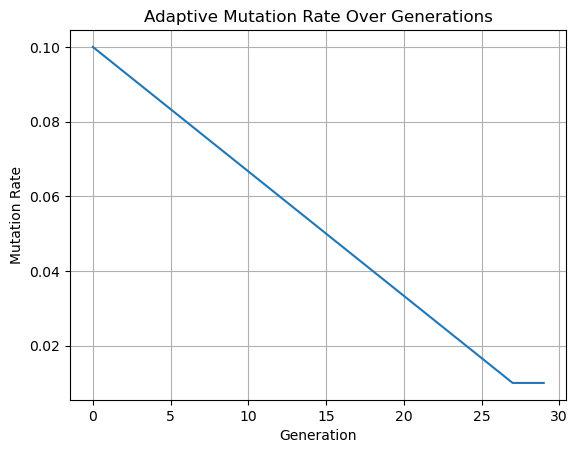

In [7]:
def adaptive_mutation(individual, generation, max_generations,
                      base_rate=0.1, min_rate=0.01):

    individual = individual.copy()

    mutation_rate = base_rate * (1 - generation / max_generations)
    mutation_rate = max(mutation_rate, min_rate)

    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i]

    if np.sum(individual) == 0:
        individual[np.random.randint(0, len(individual))] = 1

    return individual, mutation_rate


rates = []
for gen in range(30):
    _, rate = adaptive_mutation(parent1, gen, 30)
    rates.append(rate)

print("Mutation rates over generations:")
print(rates)

plt.plot(rates)
plt.title("Adaptive Mutation Rate Over Generations")
plt.xlabel("Generation")
plt.ylabel("Mutation Rate")
plt.grid()
plt.show()

In [8]:
# ده مثال عشان استخدم كل اللي عملته فوق #

population = np.random.randint(0, 2, (10, n_features))

new_population = []

for i in range(0, len(population), 2):
    p1 = population[i]
    p2 = population[i+1]

    # crossover
    if np.random.rand() < 0.5:
        c1, c2 = single_point_crossover(p1, p2)
    else:
        c1, c2 = uniform_crossover(p1, p2)

    # mutation
    c1, _ = adaptive_mutation(c1, generation=5, max_generations=30)
    c2, _ = adaptive_mutation(c2, generation=5, max_generations=30)

    new_population.extend([c1, c2])

new_population = np.array(new_population)

print("Old Population:\n", population)
print("\nNew Population:\n", new_population)

Old Population:
 [[1 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0]
 [0 1 1 1 1 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0]
 [0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]
 [0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0]
 [0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 0]
 [0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0]
 [0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1]
 [0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 0 1]
 [0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0]
 [0 0 1 1 1 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 0 1 1 0 1 1 0 0 1]]

New Population:
 [[0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 0]
 [0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0]
 [0 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 1 1 0 1 0 1 0 0]
 [0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0]
 [0 0 1 1 0 1 1 1 1